# Data storytelling notebook 1/2.
Purpose: Tell the story of how the corona pandemic impacted streaming numbers in the first year of it hitting us globally.
Dataset: Using our `silver_historical_charts`-table that spans from 2017/01/01 to 2021/12/31

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import pandas as pd

# Konstanter
DB_PATH = "../data/music_warehouse.duckdb"

# Uppkoppling mot DB
con = duckdb.connect(DB_PATH)

In [83]:
# Aggregera data per månad direkt med en SQL query för att få ner datamängden
# Bättre än att läsa in HELA table med Pandas DataFrames pga MYCKET data.

query = """
SELECT
    date_trunc('month', CAST(snapshot_date AS DATE)) AS month, -- Behöver använda CAST för att ändra datatype från VARCHAR till date
    SUM(streams) AS total_streams
FROM silver_historical_charts
WHERE CAST(snapshot_date AS DATE) >= '2017-01-01' -- Behöver använda CAST för att ändra Datatype från VARCHAR till Date
GROUP BY 1
ORDER BY 1
"""


# Dra in den färdiga aggregerade datan i en DataFrame NU när queryn redan är gjord. Bättre prestanda
df_trend = con.execute(query).df()
con.close()

In [84]:
# Säkerställ att Pandas fattar att 'month' är ett datum för att undvika problem med X axeln när det är dags att plotta.
df_trend['month'] = pd.to_datetime(df_trend['month'])

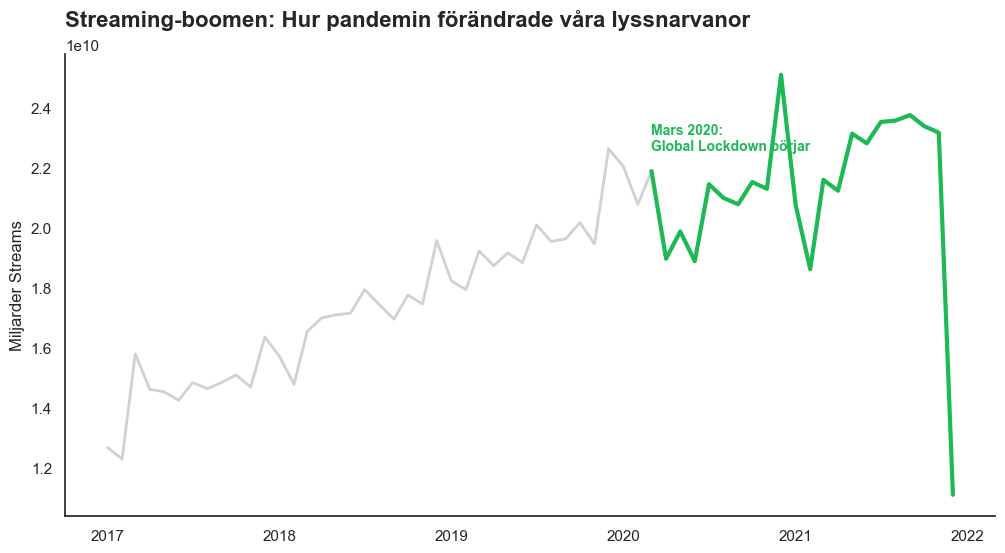

In [129]:
# Sätt stilen till en ren vit bakgrund
sns.set_theme(style="white")
plt.figure(figsize=(12, 6))

# Skapa grafen
ax = sns.lineplot(data=df_trend, x='month', y='total_streams', color='#d1d1d1', linewidth=2)

# STORYTELLING: Markera pandemin (Mars 2020) med en annan färg
pandemic_start = '2020-03-01'
df_pandemic = df_trend[df_trend['month'] >= pandemic_start]
sns.lineplot(data=df_pandemic, x='month', y='total_streams', color='#1DB954', linewidth=3, ax=ax)

# DECLUTTERING: Ta bort ramen (spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ANNOTERING: Berätta vad som händer
plt.text(pd.to_datetime('2020-03-01'), df_trend['total_streams'].max() * 0.9, 
         "Mars 2020:\nGlobal Lockdown börjar", 
         fontsize=10, fontweight='bold', color='#1DB954')

# TITEL: Action-orienterad
plt.title("Streaming-boomen: Hur pandemin förändrade våra lyssnarvanor", 
          fontsize=16, fontweight='bold', pad=20, loc='left')

plt.ylabel("Miljarder Streams")
plt.xlabel("") # Ta bort 'month' etiketten, den är självförklarande
plt.show()

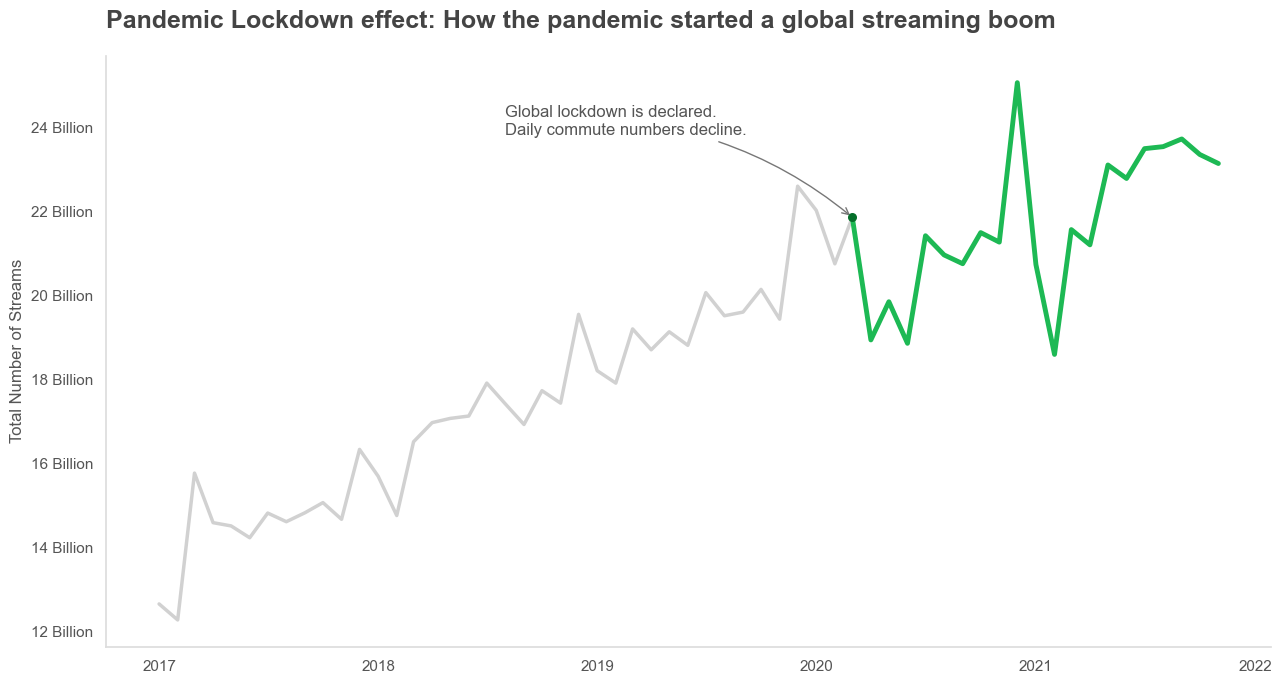

In [133]:
# Skapa en kopia (df_plot) Så att plotten ej förändras vid varje körning.
# Skumt beteende med notebook när jag körde cellen flera gånger, varje körning försvann månad efter månad efter månad.
df_plot = df_trend.iloc[:-1].copy()

# Säkerställ datetime för X-axeln på kopian ovanför
df_plot['month'] = pd.to_datetime(df_plot['month'])

# Ren och vit bakgrund
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(13, 7))

# Rita grundlinjen (grå som KC pratade om i klassrummet)
sns.lineplot(data=df_plot, x='month', y='total_streams', color='#d1d1d1', linewidth=2.5, ax=ax)

# STORYTELLING: Pandemi-overlay (SPOTIFY grön)
pandemic_start = pd.to_datetime('2020-03-01')
df_pandemic = df_plot[df_plot['month'] >= pandemic_start]
sns.lineplot(data=df_pandemic, x='month', y='total_streams', color='#1DB954', linewidth=3.5, ax=ax)

# DECLUTTERING: Göm ramarna helt
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#dddddd')

# ANNOTERING
# Hämtar Y-värdet för mars 2020 från kopian högst upp
y_value_march = df_plot.loc[df_plot['month'] == pandemic_start, 'total_streams'].values[0]

# Den gröna punkten
plt.scatter(pandemic_start, y_value_march, color="#056F2A", s=30, zorder=5)

# Text och pilen
plt.annotate(
    "Global lockdown is declared.\nDaily commute numbers decline.",
    xy=(pandemic_start, y_value_march),
    xytext=(pd.to_datetime('2018-08-01'), y_value_march * 1.09),
    arrowprops=dict(facecolor='#777777', edgecolor='#777777', arrowstyle="->", connectionstyle="arc3,rad=-0.15"),
    fontsize=12, 
    color='#555555' 
)

# TITEL
plt.title("Pandemic Lockdown effect: How the pandemic started a global streaming boom", 
          fontsize=18, fontweight='bold', color='#444444', pad=20, loc='left')

plt.ylabel("Total Number of Streams", fontsize=12, color='#555555')
plt.xlabel("") 

# Y-AXEL UX: Gör om siffror till "Billion"
def billion_formatter(x, pos):
    return f"{x * 1e-9:.0f} Billion"

ax.yaxis.set_major_formatter(plt.FuncFormatter(billion_formatter))

# Gör färgerna på axlarnas text till "mjukt" gråa
ax.tick_params(axis='y', colors='#555555')
ax.tick_params(axis='x', colors='#555555')

plt.tight_layout()
plt.show()

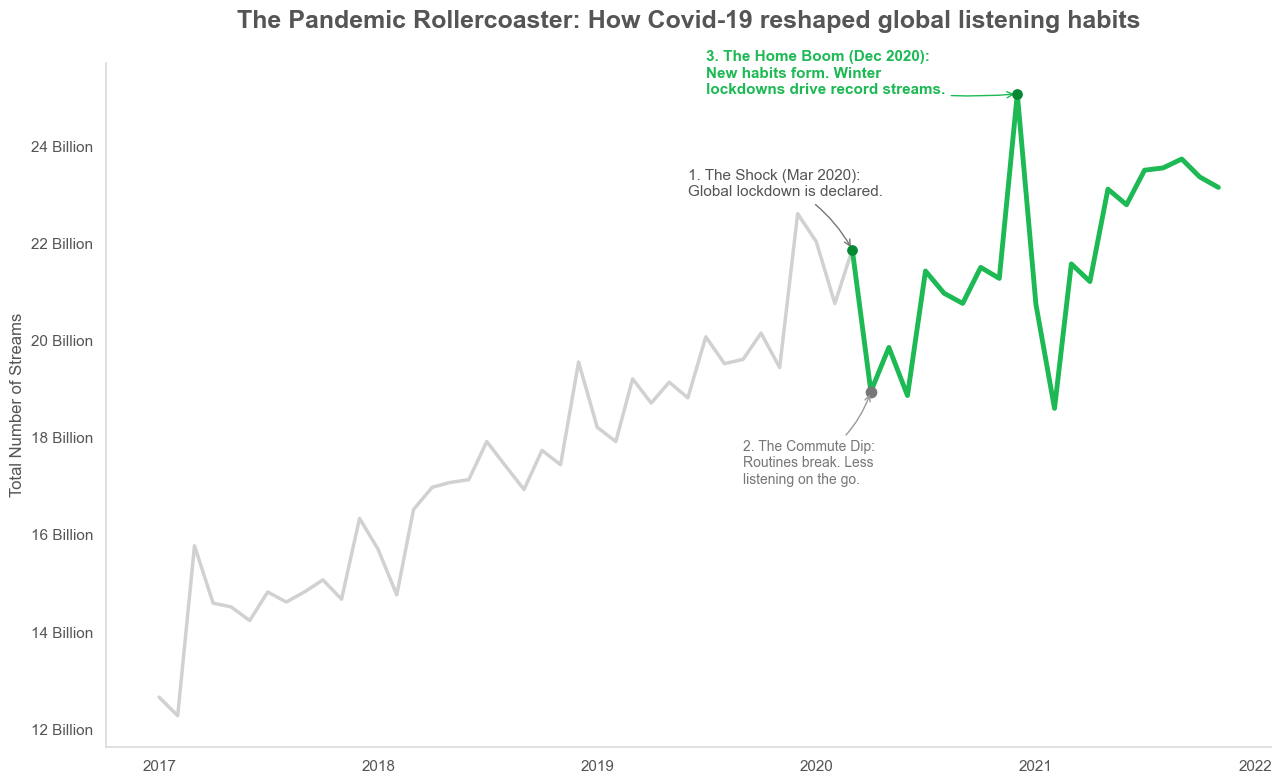

In [182]:
# Skapa en kopia (df_plot) Så att plotten ej förändras vid varje körning.
# Skumt beteende med notebook när jag körde cellen flera gånger, varje körning försvann månad efter månad efter månad.
df_plot = df_trend.iloc[:-1].copy() # Säkerställ datetime för X-axeln på kopian ovanför
df_plot['month'] = pd.to_datetime(df_plot['month'])

# 1) Grundinställningarna. Ren och vit bakgrund
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(13, 8)) # Aningen större och bredare för att få plats med hela storyn


# 2) Rita alla linjer för vår Pandemi-overlay (SPOTIFY grön = #1DB954)
sns.lineplot(data = df_plot, x = 'month', y = 'total_streams', color = '#d1d1d1', linewidth = 2.5, ax = ax)
pandemic_start = pd.to_datetime('2020-03-01')
df_pandemic = df_plot[df_plot['month'] >= pandemic_start]
sns.lineplot(data = df_pandemic, x = 'month', y = 'total_streams', color = '#1DB954', linewidth = 3.5, ax = ax)
             
# 3) Göm spines och ramar
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#dddddd')

# ========================================
# 4) STORYTELLING: Tre faser enligt grafen
# ========================================

# FAS 1 - Lockdown (Mars 2020)
y_march = df_plot.loc[df_plot['month'] == pandemic_start, 'total_streams'].values[0]
plt.scatter(pandemic_start, y_march, color = "#048932", s = 45, zorder = 5)
plt.annotate(
    "1. The Shock (Mar 2020):\nGlobal lockdown is declared.",
    xy=(pandemic_start, y_march),
    xytext=(pd.to_datetime('2019-06-01'), y_march * 1.05),
    arrowprops=dict(facecolor='#777777', edgecolor='#777777', arrowstyle="->", connectionstyle="arc3,rad=-0.15"),
    fontsize=11, color='#555555' 
)

# FAS 2 - Dippen, pendlingen dör
dip_date = pd.to_datetime('2020-04-01') 
try:
    y_dip = df_plot.loc[df_plot['month'] == dip_date, 'total_streams'].values[0]
    plt.scatter(dip_date, y_dip, color='#777777', s=55, zorder=2) # Mindre grå prick för dippen
    plt.annotate(
        "2. The Commute Dip:\nRoutines break. Less\nlistening on the go.",
        xy=(dip_date, y_dip),
        xytext=(pd.to_datetime('2019-09-01'), y_dip * 0.9), # Placerar texten UNDER kurvan
        arrowprops=dict(facecolor='#999999', edgecolor='#999999', arrowstyle="->", connectionstyle="arc3,rad=0.2"),
        fontsize=10, color='#777777'
    )
except IndexError:
    pass

# FAS 3 - Peaken, nya vanor, folk börjar jobba hemifrån och gör livet enklare och bättre under lockdown
peak_date = pd.to_datetime('2020-12-01')
try:
    y_peak = df_plot.loc[df_plot['month'] == peak_date, 'total_streams'].values[0]
    plt.scatter(peak_date, y_peak, color='#048932', s=45, zorder=5)
    plt.annotate(
        "3. The Home Boom (Dec 2020):\nNew habits form. Winter\nlockdowns drive record streams.",
        xy=(peak_date, y_peak),
        xytext=(pd.to_datetime('2019-07-01'), y_peak * 1), # Placerar texten till vänster om toppen
        arrowprops=dict(facecolor='#1DB954', edgecolor='#1DB954', arrowstyle="->", connectionstyle="arc3,rad=0.1"),
        fontsize=11, color='#1DB954', fontweight='bold'
    )
except IndexError:
    pass

# ==========================================
# 5) TITEL
plt.title("The Pandemic Rollercoaster: How Covid-19 reshaped global listening habits", 
          fontsize=18, fontweight='bold', color="#555555", pad=25, loc='center')

plt.ylabel("Total Number of Streams", fontsize=12, color='#555555')
plt.xlabel("") 

# 6. Formatera Y-axeln till miljarder
def billion_formatter(x, pos):
    return f"{x * 1e-9:.0f} Billion"
ax.yaxis.set_major_formatter(plt.FuncFormatter(billion_formatter))
ax.tick_params(axis='both', colors='#555555')

plt.tight_layout()
plt.show()
